In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Global Superstore.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [17]:
df.shape

(51290, 24)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


In [8]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [20]:
#Overall Sales Profit & Quantity
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())

Total Sales: 12642501.909880001
Total Profit: 1467457.2912800002
Total Quantity: 178312


In [21]:
#Profit Margins
profit_margin = (df["Profit"].sum() / df["Sales"].sum()) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 11.61 %


In [22]:
#Sales & Profit by Category
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

category_analysis.sort_values("Sales", ascending=False)

,Sales,Profit
Category,,
Technology,4.744557e+06,663778.73318
Furniture,4.110874e+06,285204.72380
Office Supplies,3.787070e+06,518473.83430


In [23]:
category_analysis.sort_values("Profit", ascending=False)

,Sales,Profit
Category,,
Technology,4.744557e+06,663778.73318
Office Supplies,3.787070e+06,518473.83430
Furniture,4.110874e+06,285204.72380


In [24]:
#Sub Category Analysis
subcategory_analysis = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_analysis.sort_values("Sales", ascending=False)

,Sales,Profit
Sub-Category,,
Phones,1.706824e+06,216717.00580
Copiers,1.509436e+06,258567.54818
Chairs,1.501682e+06,140396.26750
Bookcases,1.466572e+06,161924.41950
Storage,1.127086e+06,108461.48980
Appliances,1.011064e+06,141680.58940
Machines,7.790601e+05,58867.87300
Tables,7.570419e+05,-64083.38870
Accessories,7.492370e+05,129626.30620


In [25]:
#Top 10 Profitable Products
subcategory_analysis.sort_values("Profit", ascending=False).head(10)

,Sales,Profit
Sub-Category,,
Copiers,1.509436e+06,258567.54818
Phones,1.706824e+06,216717.00580
Bookcases,1.466572e+06,161924.41950
Appliances,1.011064e+06,141680.58940
Chairs,1.501682e+06,140396.26750
Accessories,7.492370e+05,129626.30620
Storage,1.127086e+06,108461.48980
Binders,4.619115e+05,72449.84600
Paper,2.442917e+05,59207.68270


In [26]:
#Top 10 Loss Making Products
subcategory_analysis.sort_values("Profit", ascending=True).head(10)

,Sales,Profit
Sub-Category,,
Tables,757041.9244,-64083.3887
Fasteners,83242.3159,11525.4241
Labels,73404.0300,15010.5120
Supplies,243074.2206,22583.2631
Envelopes,170904.3016,29601.1163
Furnishings,385578.2559,46967.4255
Art,372091.9659,57953.9109
Machines,779060.0671,58867.8730
Paper,244291.7194,59207.6827


In [27]:
#Region Analysis
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

region_analysis.sort_values("Sales", ascending=False)

,Sales,Profit
Region,,
Central,2.822303e+06,311403.98164
South,1.600907e+06,140355.76618
North,1.248166e+06,194597.95252
Oceania,1.100185e+06,120089.11200
Southeast Asia,8.844232e+05,17852.32900
North Asia,8.483098e+05,165578.42100
EMEA,8.061613e+05,43897.97100
Africa,7.837732e+05,88871.63100
Central Asia,7.528266e+05,132480.18700


In [28]:
region_analysis.sort_values("Profit", ascending=False)

,Sales,Profit
Region,,
Central,2.822303e+06,311403.98164
North,1.248166e+06,194597.95252
North Asia,8.483098e+05,165578.42100
South,1.600907e+06,140355.76618
Central Asia,7.528266e+05,132480.18700
Oceania,1.100185e+06,120089.11200
West,7.254578e+05,108418.44890
East,6.787812e+05,91522.78000
Africa,7.837732e+05,88871.63100


In [29]:
#Country Analysis
country_analysis = df.groupby("Country")[["Sales", "Profit"]].sum()

country_analysis.sort_values("Sales", ascending=False).head(10)

,Sales,Profit
Country,,
United States,2.297201e+06,286397.02170
Australia,9.252359e+05,103907.43300
France,8.589311e+05,109029.00300
China,7.005620e+05,150683.08500
Germany,6.288400e+05,107322.82050
Mexico,6.225906e+05,102818.09752
India,5.896501e+05,129071.83500
United Kingdom,5.285763e+05,111900.15000
Indonesia,4.048875e+05,15608.67790


In [30]:
#Top Profitable Countries
country_analysis.sort_values("Profit", ascending=False).head(10)

,Sales,Profit
Country,,
United States,2.297201e+06,286397.02170
China,7.005620e+05,150683.08500
India,5.896501e+05,129071.83500
United Kingdom,5.285763e+05,111900.15000
France,8.589311e+05,109029.00300
Germany,6.288400e+05,107322.82050
Australia,9.252359e+05,103907.43300
Mexico,6.225906e+05,102818.09752
Spain,2.871467e+05,54390.12000


In [31]:
#Loss Making Countries
country_analysis.sort_values("Profit").head(10)

,Sales,Profit
Country,,
Turkey,108507.94800,-98447.23200
Nigeria,54350.35200,-80750.71800
Netherlands,77514.94500,-41070.07500
Honduras,90125.64860,-29482.37140
Pakistan,58872.61200,-22446.64800
Argentina,57511.78328,-18693.79672
Panama,51539.92752,-17723.45248
Sweden,30491.40300,-17519.36700
Philippines,183420.16500,-16128.22500


In [32]:
#Category Analysis
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

category_analysis

,Sales,Profit
Category,,
Furniture,4.110874e+06,285204.72380
Office Supplies,3.787070e+06,518473.83430
Technology,4.744557e+06,663778.73318


In [33]:
#PROFIT Margin for each Category
category_analysis["Profit Margin"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
) * 100

category_analysis.sort_values("Sales", ascending=False)

,Sales,Profit,Profit Margin
Category,,,
Technology,4.744557e+06,663778.73318,13.990319
Furniture,4.110874e+06,285204.72380,6.937812
Office Supplies,3.787070e+06,518473.83430,13.690632


In [34]:
category_analysis.sort_values("Profit", ascending=False)

,Sales,Profit,Profit Margin
Category,,,
Technology,4.744557e+06,663778.73318,13.990319
Office Supplies,3.787070e+06,518473.83430,13.690632
Furniture,4.110874e+06,285204.72380,6.937812


In [35]:
category_analysis.sort_values("Profit", ascending=True)

,Sales,Profit,Profit Margin
Category,,,
Furniture,4.110874e+06,285204.72380,6.937812
Office Supplies,3.787070e+06,518473.83430,13.690632
Technology,4.744557e+06,663778.73318,13.990319


In [37]:
#Sub-Category
subcategory_analysis = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_analysis["Profit Margin"] = (
    subcategory_analysis["Profit"] / subcategory_analysis["Sales"]
) * 100

subcategory_analysis.sort_values("Profit", ascending=False)

,Sales,Profit,Profit Margin
Sub-Category,,,
Copiers,1.509436e+06,258567.54818,17.130074
Phones,1.706824e+06,216717.00580,12.697091
Bookcases,1.466572e+06,161924.41950,11.041012
Appliances,1.011064e+06,141680.58940,14.013015
Chairs,1.501682e+06,140396.26750,9.349269
Accessories,7.492370e+05,129626.30620,17.301108
Storage,1.127086e+06,108461.48980,9.623179
Binders,4.619115e+05,72449.84600,15.684789
Paper,2.442917e+05,59207.68270,24.236467


In [38]:
subcategory_analysis.sort_values("Profit", ascending=True)

,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,7.570419e+05,-64083.38870,-8.464972
Fasteners,8.324232e+04,11525.42410,13.845631
Labels,7.340403e+04,15010.51200,20.449166
Supplies,2.430742e+05,22583.26310,9.290686
Envelopes,1.709043e+05,29601.11630,17.320287
Furnishings,3.855783e+05,46967.42550,12.181036
Art,3.720920e+05,57953.91090,15.575158
Machines,7.790601e+05,58867.87300,7.556269
Paper,2.442917e+05,59207.68270,24.236467


In [39]:
#Tables by Region
tables_region = df[df["Sub-Category"] == "Tables"].groupby("Region")[["Sales", "Profit"]].sum()

tables_region["Profit Margin"] = (
    tables_region["Profit"] / tables_region["Sales"]
) * 100

tables_region.sort_values("Profit")

,Sales,Profit,Profit Margin
Region,,,
South,104892.4680,-27012.3219,-25.752394
Central,133129.9845,-21550.1069,-16.187268
Southeast Asia,52455.4149,-18618.3051,-35.493581
East,39139.8070,-11025.3801,-28.169224
North Asia,54300.4320,-5470.5780,-10.074649
Oceania,66830.9910,-229.7190,-0.343731
Caribbean,23661.3080,63.3880,0.267897
Canada,849.3600,300.1800,35.341904
West,84754.5620,1482.6073,1.749295


In [40]:
#Tables by Country
tables_country = df[df["Sub-Category"] == "Tables"].groupby("Country")[["Sales", "Profit"]].sum()

tables_country["Profit Margin"] = (
    tables_country["Profit"] / tables_country["Sales"]
) * 100

tables_country.sort_values("Profit").head(10)

,Sales,Profit,Profit Margin
Country,,,
United States,206965.5320,-17725.4811,-8.564460
Indonesia,32502.9549,-10680.2751,-32.859397
Germany,24764.8785,-7375.7415,-29.783072
France,32738.4330,-5918.7570,-18.078926
Italy,10382.9100,-5811.6900,-55.973614
Pakistan,2240.0040,-5338.8060,-238.339128
Argentina,3438.4500,-5188.6500,-150.900842
Dominican Republic,3159.4800,-4739.1000,-149.996202
China,43613.2200,-4552.8900,-10.439243


In [41]:
#Tables and Discount
tables_discount = df[df["Sub-Category"] == "Tables"].groupby("Discount")[["Sales", "Profit"]].sum()

tables_discount

,Sales,Profit
Discount,,
0.00,261809.3500,60447.1997
0.10,3481.4070,795.0270
0.20,157722.7360,7215.5360
0.30,104750.2890,-11960.4786
0.35,54160.0410,-9122.6490
0.40,52156.4520,-17105.1808
0.45,2546.4285,-1103.1915
0.45,5484.9740,-2493.1111
0.47,32502.9549,-10680.2751


In [42]:
#Discount + Profit Margin
tables_discount = df[df["Sub-Category"] == "Tables"].groupby("Discount")[["Sales", "Profit"]].sum()

tables_discount["Profit Margin"] = (
    tables_discount["Profit"] / tables_discount["Sales"]
) * 100

tables_discount

,Sales,Profit,Profit Margin
Discount,,,
0.00,261809.3500,60447.1997,23.088251
0.10,3481.4070,795.0270,22.836370
0.20,157722.7360,7215.5360,4.574823
0.30,104750.2890,-11960.4786,-11.418086
0.35,54160.0410,-9122.6490,-16.843874
0.40,52156.4520,-17105.1808,-32.795906
0.45,2546.4285,-1103.1915,-43.323090
0.45,5484.9740,-2493.1111,-45.453472
0.47,32502.9549,-10680.2751,-32.859397


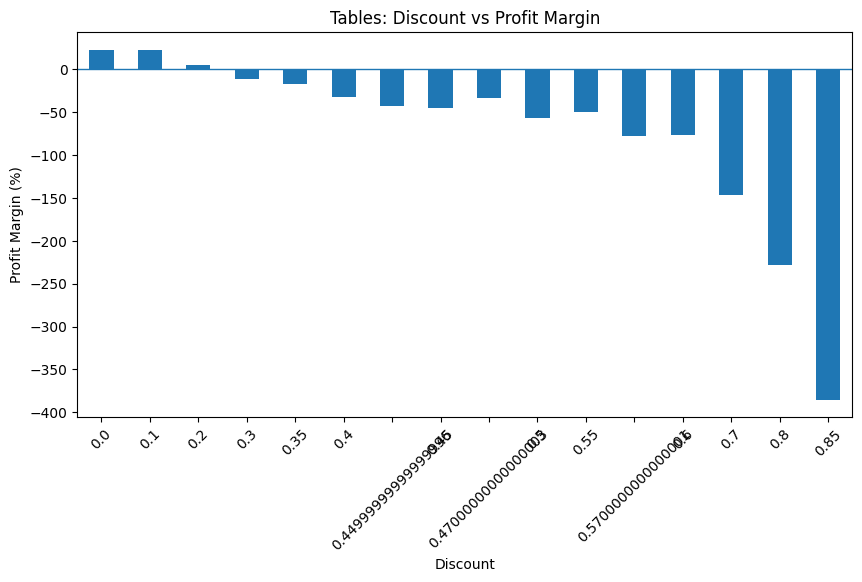

In [43]:
tables_discount["Profit Margin"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Tables: Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.show()

In [44]:
tables_products = df[df["Sub-Category"] == "Tables"].groupby(
    "Product Name"
)[["Sales", "Profit"]].sum()

tables_products.sort_values("Profit").head(10)

,Sales,Profit
Product Name,,
"Bevis Round Table, Adjustable Height",5654.7960,-3649.8940
"Bevis Computer Table, Fully Assembled",11177.8962,-3509.5638
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.6400,-2876.1156
"Bevis Wood Table, with Bottom Storage",11134.6620,-2782.5880
"Lesro Training Table, Rectangular",2711.6466,-2581.2834
"Barricks Conference Table, Rectangular",3663.8325,-2487.9675
"Bevis Conference Table, Fully Assembled",14886.9507,-2443.0893
"Lesro Round Table, Adjustable Height",3960.6240,-2402.9760
"Lesro Computer Table, Fully Assembled",7223.2620,-2322.8380


In [45]:
#Order Date
df["Order Date"].dtype

dtype('<M8[ns]')

In [46]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

In [47]:
#Year Column
df["Year"] = df["Order Date"].dt.year

In [48]:
df["Year"].value_counts().sort_index()

Year
2011     8998
2012    10962
2013    13799
2014    17531
Name: count, dtype: int64

In [49]:
#Year-wise Sales & Profit
year_analysis = df.groupby("Year")[["Sales", "Profit"]].sum()

year_analysis

,Sales,Profit
Year,,
2011,2.259451e+06,248940.81154
2012,2.677439e+06,307415.27910
2013,3.405746e+06,406935.23018
2014,4.299866e+06,504165.97046


In [50]:
#Profit Margin
year_analysis["Profit Margin"] = (
    year_analysis["Profit"] / year_analysis["Sales"]
) * 100

year_analysis

,Sales,Profit,Profit Margin
Year,,,
2011,2.259451e+06,248940.81154,11.017757
2012,2.677439e+06,307415.27910,11.481693
2013,3.405746e+06,406935.23018,11.948489
2014,4.299866e+06,504165.97046,11.725156


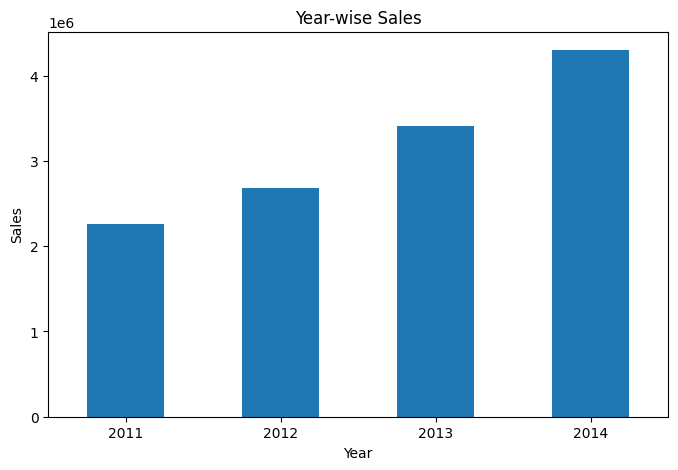

In [51]:
#Year-wise Sales
year_analysis["Sales"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

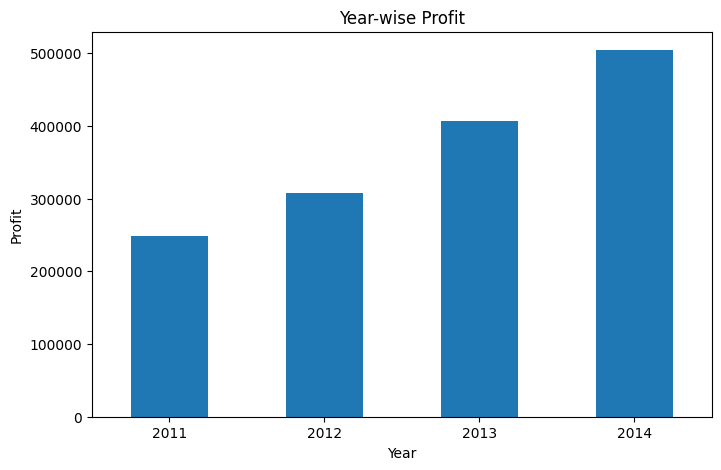

In [52]:
#Profit wise Profit
year_analysis["Profit"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Year-wise Profit")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [53]:
#Monthly Sales & Profit Analysis
df["Month"] = df["Order Date"].dt.month

In [54]:
df["Month Name"] = df["Order Date"].dt.month_name()

In [55]:
monthly_analysis = df.groupby(
    df["Order Date"].dt.to_period("M")
)[["Sales", "Profit"]].sum()

monthly_analysis.head()

,Sales,Profit
Order Date,,
2011-01,98898.48886,8321.80096
2011-02,91152.15698,12417.90698
2011-03,145729.36736,15303.56826
2011-04,116915.76418,12902.32438
2011-05,146747.83610,12183.82870


In [56]:
monthly_analysis["Profit Margin"] = (
    monthly_analysis["Profit"] / monthly_analysis["Sales"]
) * 100

monthly_analysis

,Sales,Profit,Profit Margin
Order Date,,,
2011-01,98898.48886,8321.80096,8.414487
2011-02,91152.15698,12417.90698,13.623273
2011-03,145729.36736,15303.56826,10.501362
2011-04,116915.76418,12902.32438,11.035573
2011-05,146747.83610,12183.82870,8.302561
2011-06,215207.38022,23415.24702,10.880318
2011-07,115510.41912,5585.00352,4.835065
2011-08,207581.49122,23713.66772,11.423787
2011-09,290214.45534,35776.88394,12.327740


In [57]:
#Top 10 Months by Sales
monthly_analysis.sort_values(
    "Sales", ascending=False
).head(10)

,Sales,Profit,Profit Margin
Order Date,,,
2014-11,555279.02700,62856.58790,11.319820
2014-12,503143.69348,46916.52068,9.324676
2014-09,481157.24370,67979.45110,14.128323
2014-08,456619.94236,53542.89496,11.725921
2014-10,422766.62916,58209.83476,13.768787
2013-12,405454.37802,50202.87112,12.381879
2014-06,401814.06310,43778.60280,10.895239
2013-06,396519.61190,45478.41340,11.469398
2013-09,376619.24568,38905.66778,10.330239


In [58]:
#Worst 10 Months by Profit
monthly_analysis.sort_values(
    "Profit", ascending=True
).head(10)

,Sales,Profit,Profit Margin
Order Date,,,
2011-07,115510.41912,5585.00352,4.835065
2011-01,98898.48886,8321.80096,8.414487
2012-01,135780.72024,10401.63764,7.660615
2011-05,146747.83610,12183.82870,8.302561
2011-02,91152.15698,12417.90698,13.623273
2011-04,116915.76418,12902.32438,11.035573
2012-02,100510.21698,15000.09618,14.923952
2011-03,145729.36736,15303.56826,10.501362
2012-07,145236.78512,15585.38842,10.731020


In [59]:
#Region Performance
region_analysis = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum"
})

region_analysis["Profit Margin"] = (
    region_analysis["Profit"] / region_analysis["Sales"]
) * 100

region_analysis = region_analysis.sort_values("Profit", ascending=False)

region_analysis

,Sales,Profit,Profit Margin
Region,,,
Central,2.822303e+06,311403.98164,11.033685
North,1.248166e+06,194597.95252,15.590716
North Asia,8.483098e+05,165578.42100,19.518627
South,1.600907e+06,140355.76618,8.767265
Central Asia,7.528266e+05,132480.18700,17.597703
Oceania,1.100185e+06,120089.11200,10.915360
West,7.254578e+05,108418.44890,14.944831
East,6.787812e+05,91522.78000,13.483399
Africa,7.837732e+05,88871.63100,11.338947


In [60]:
#Category Performance
category_analysis = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum"
})

category_analysis["Profit Margin"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
) * 100

category_analysis = category_analysis.sort_values("Profit", ascending=False)

category_analysis

,Sales,Profit,Profit Margin
Category,,,
Technology,4.744557e+06,663778.73318,13.990319
Office Supplies,3.787070e+06,518473.83430,13.690632
Furniture,4.110874e+06,285204.72380,6.937812


In [61]:
#Region + Category
region_category = df.groupby(["Region", "Category"]).agg({
    "Sales": "sum",
    "Profit": "sum"
})

region_category["Profit Margin"] = (
    region_category["Profit"] / region_category["Sales"]
) * 100

region_category.sort_values("Profit", ascending=False)

Sales        Profit  Profit Margin
Region         Category                                                  
Central        Technology       1.038450e+06  135538.42064      13.051997
               Office Supplies  9.234353e+05  121314.72090      13.137328
North          Technology       4.958022e+05   99272.49152      20.022599
North Asia     Technology       3.140385e+05   72471.01500      23.077108
South          Office Supplies  5.151613e+05   67495.99880      13.101915
North          Office Supplies  3.747335e+05   64403.39300      17.186454
Central Asia   Technology       3.056973e+05   56439.97500      18.462699
Oceania        Technology       4.080030e+05   54734.02200      13.415103
Central        Furniture        8.604176e+05   54550.84010       6.340042
West           Office Supplies  2.208532e+05   52609.84900      23.821180
North Asia     Furniture        3.357165e+05   52181.30100      15.543266
South          Technology       5.699961e+05   50208.13928       8.808506
Central Asia   Furniture        2.843629e+05   48935.71200      17.208895
East           Technology       2.649740e+05   47462.03510      17.911961
West           Technology       2.519918e+05   44303.64960      17.581383
Africa         Technology       3.223670e+05   44129.49300      13.689207
East           Office Supplies  2.055161e+05   41014.57910      19.956873
North Asia     Office Supplies  1.985548e+05   40926.10500      20.611997
Oceania        Office Supplies  2.817136e+05   33306.18600      11.822710
               Furniture        4.104680e+05   32048.90400       7.807893
North          Furniture        3.776299e+05   30922.06800       8.188458
Africa         Office Supplies  2.667555e+05   28480.05300      10.676462
Central Asia   Office Supplies  1.627664e+05   27104.50000      16.652398
South          Furniture        5.157496e+05   22651.62810       4.391982
Southeast Asia Technology       3.297514e+05   20948.84400       6.352921
EMEA           Technology       3.008546e+05   17494.44300       5.814917
Africa         Furniture        1.946506e+05   16262.08500       8.354499
EMEA           Office Supplies  2.766860e+05   14869.39200       5.374104
Caribbean      Office Supplies  8.957542e+04   14818.27600      16.542793
               Technology       1.163330e+05   13529.58504      11.630045
EMEA           Furniture        2.286207e+05   11534.13600       5.045096
West           Furniture        2.526127e+05   11504.95030       4.554382
Canada         Office Supplies  3.003408e+04    7957.53000      26.495002
               Technology       2.629881e+04    7246.62000      27.554935
Caribbean      Furniture        1.183724e+05    6223.46000       5.257526
Southeast Asia Office Supplies  2.412851e+05    4173.25150       1.729594
East           Furniture        2.082912e+05    3046.16580       1.462455
Canada         Furniture        1.059528e+04    2613.24000      24.664190
Southeast Asia Furniture        3.133867e+05   -7269.76650      -2.319743

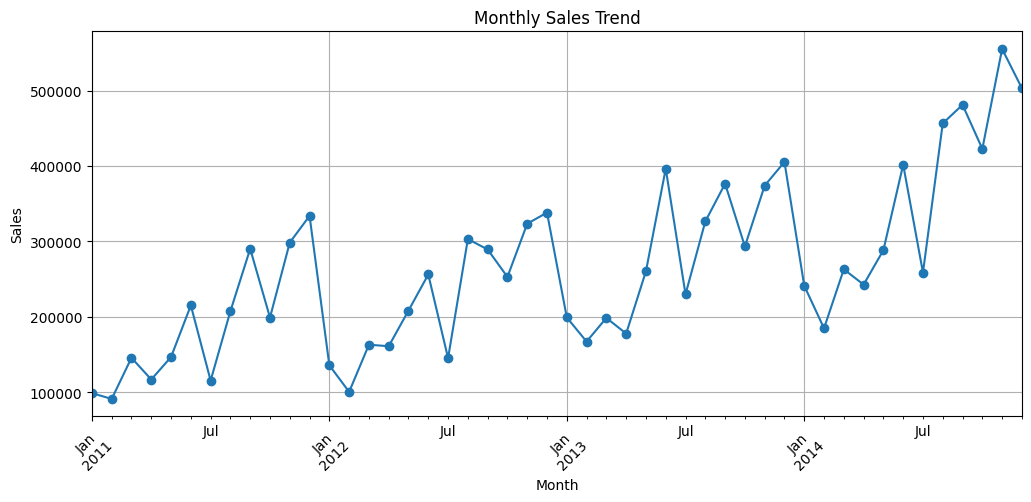

In [62]:
#Monthly Sales Trend
import matplotlib.pyplot as plt

monthly_analysis["Sales"].plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

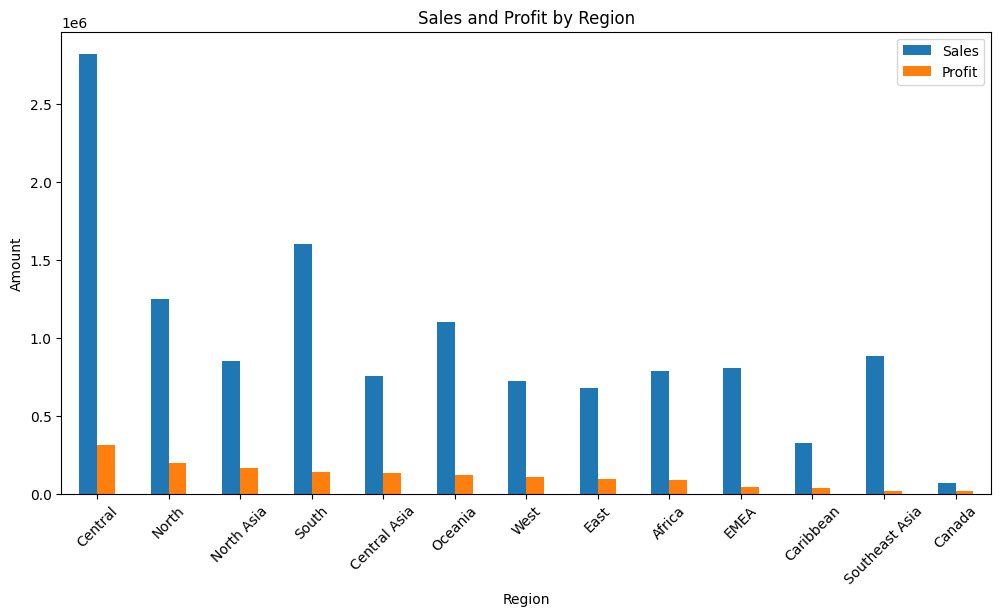

In [63]:
#Region Sales & Profit
region_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.show()

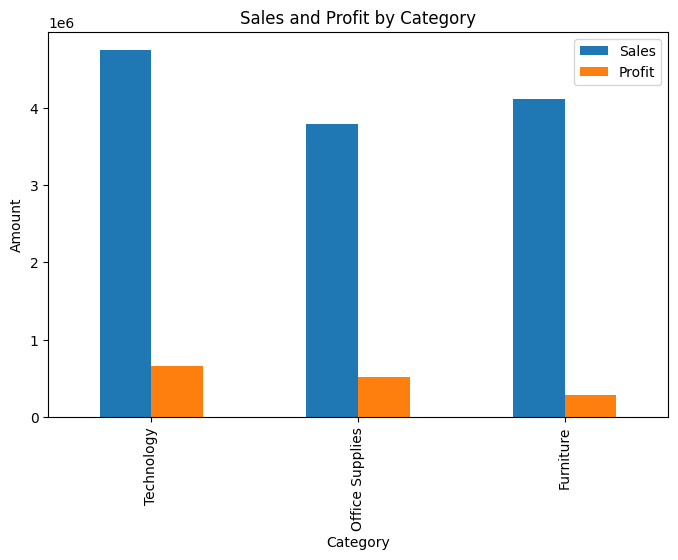

In [64]:
#Category Sales & Profit
category_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.legend()
plt.show()

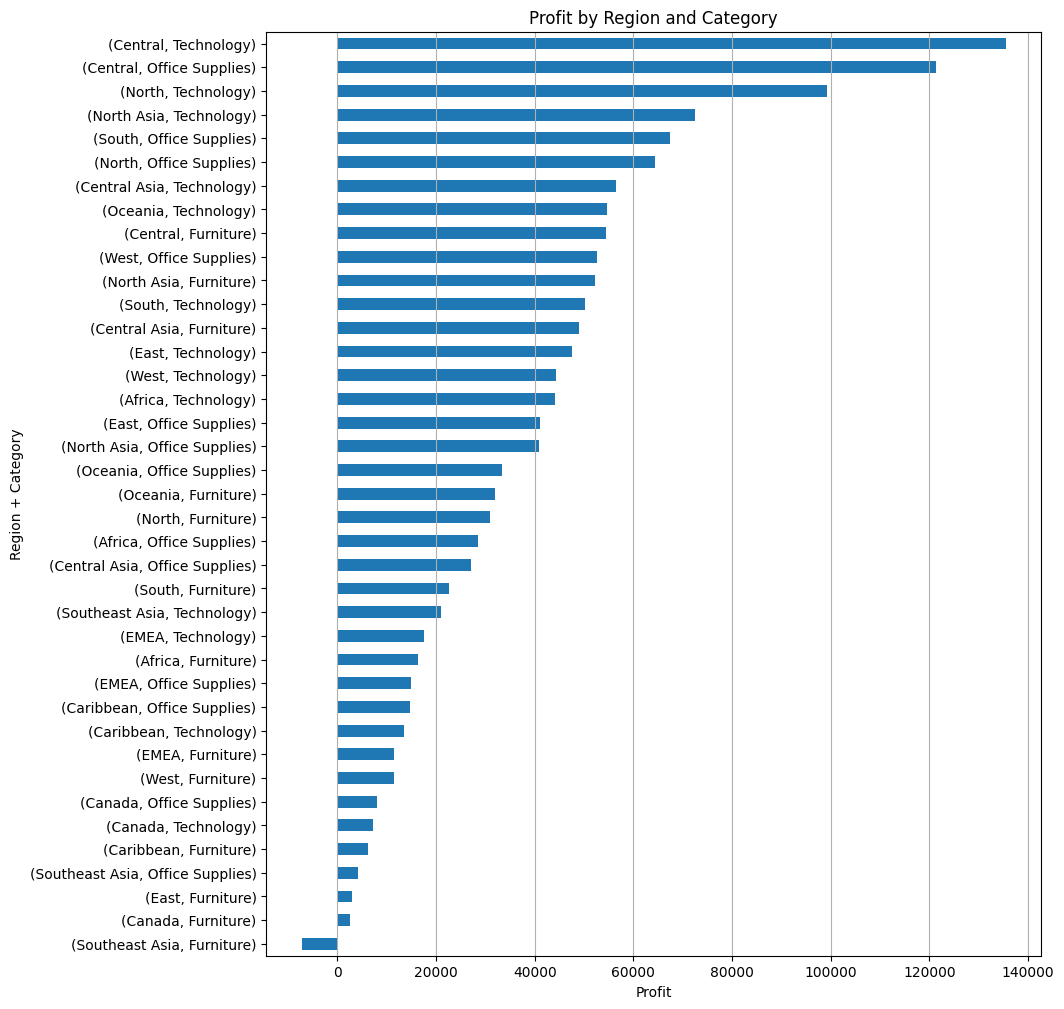

In [65]:
#Region + Category Profit
region_category["Profit"].sort_values().plot(
    kind="barh",
    figsize=(10, 12)
)

plt.title("Profit by Region and Category")
plt.xlabel("Profit")
plt.ylabel("Region + Category")
plt.grid(axis="x")
plt.show()

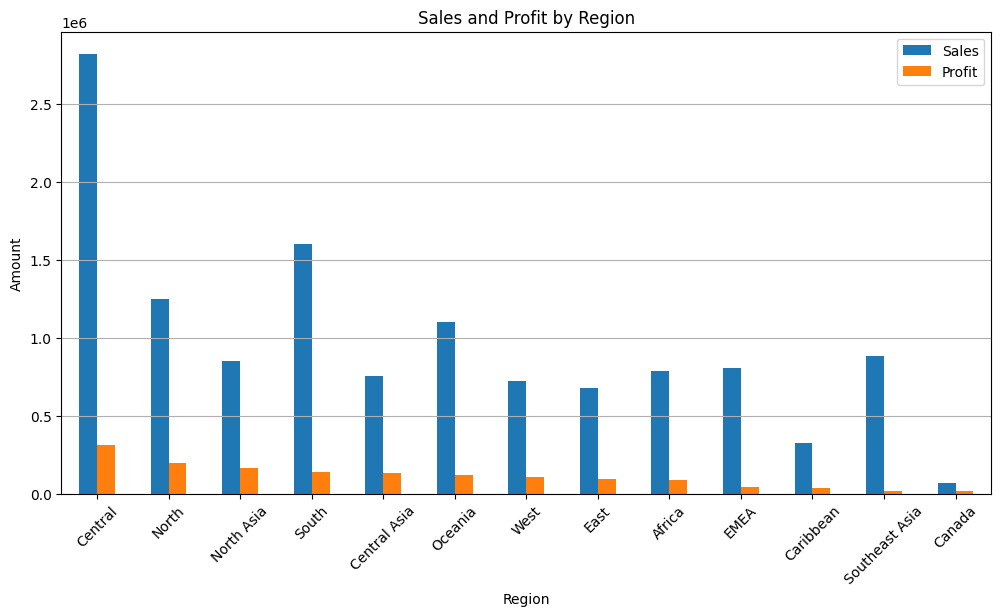

In [66]:
#Region Sales & Profit
region_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Sales", "Profit"])
plt.grid(axis="y")
plt.show()

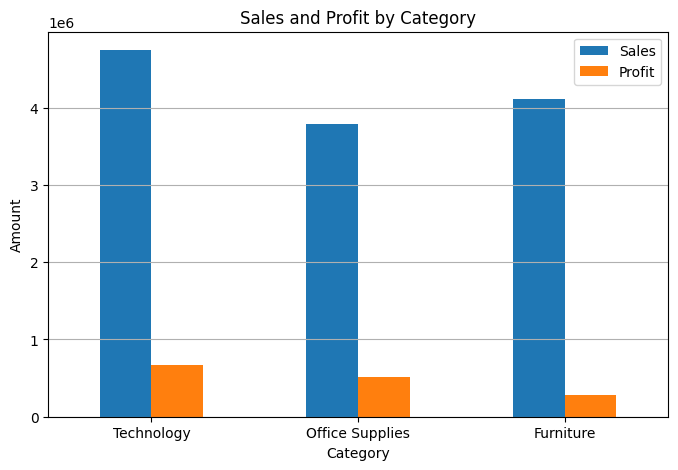

In [67]:
#Category Sales & Profit
category_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.grid(axis="y")
plt.show()

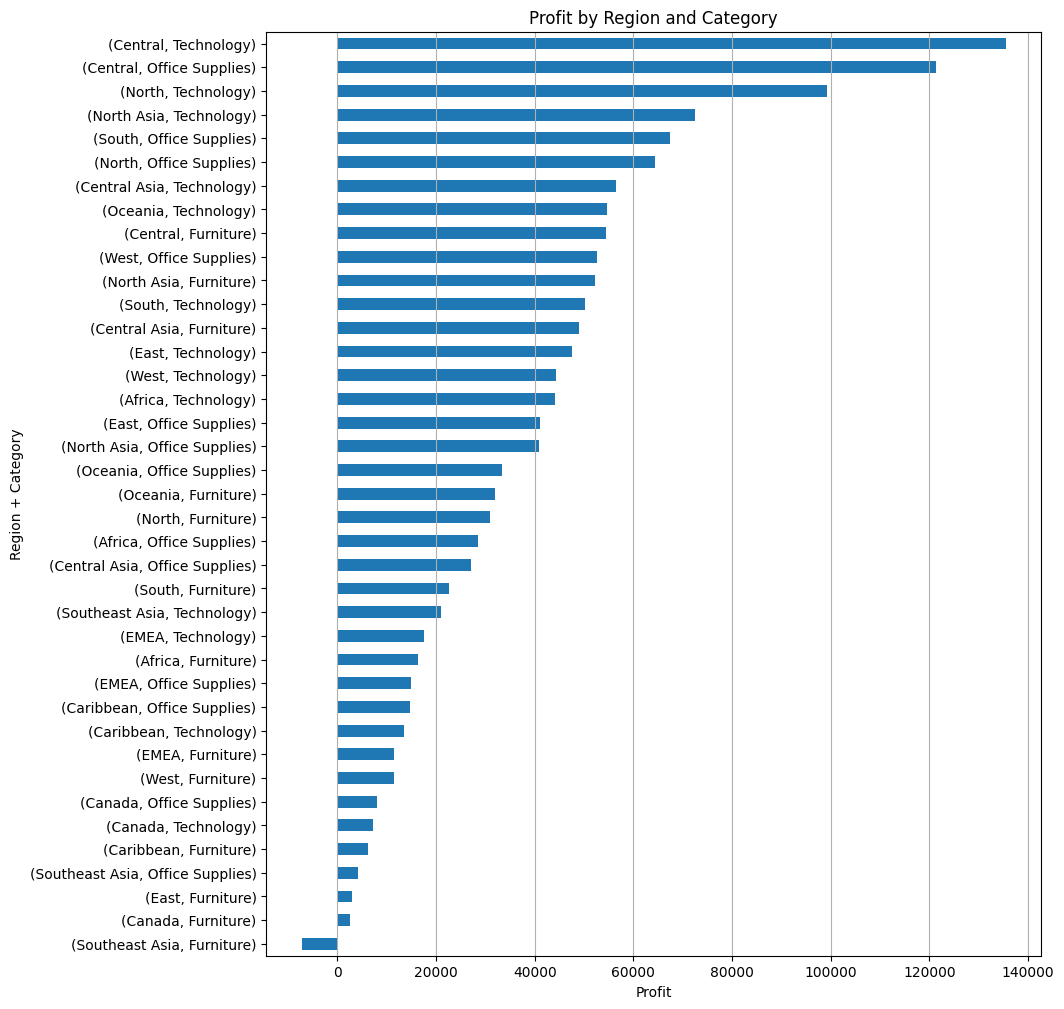

In [68]:
#Region + Category Profit
region_category["Profit"].sort_values().plot(
    kind="barh",
    figsize=(10, 12)
)

plt.title("Profit by Region and Category")
plt.xlabel("Profit")
plt.ylabel("Region + Category")
plt.grid(axis="x")
plt.show()